In [5]:
version
#https://cloud.tencent.com/developer/article/1332506

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          4.2                         
year           2024                        
month          10                          
day            31                          
svn rev        87279                       
language       R                           
version.string R version 4.4.2 (2024-10-31)
nickname       Pile of Leaves              

In [6]:
library("ChIPseeker")

In [7]:
library("org.Hs.eg.db")
library("TxDb.Hsapiens.UCSC.hg38.knownGene")
library("clusterProfiler")
txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

In [9]:
setwd("/mnt/zhangzheng_group/liuz-53/other/ENCSR230ZWH_GSE95993/RAD21_human/GSM2527620/SRR5331455/")
rep2<-readPeakFile("rep2_peaks.narrowPeak_clean")

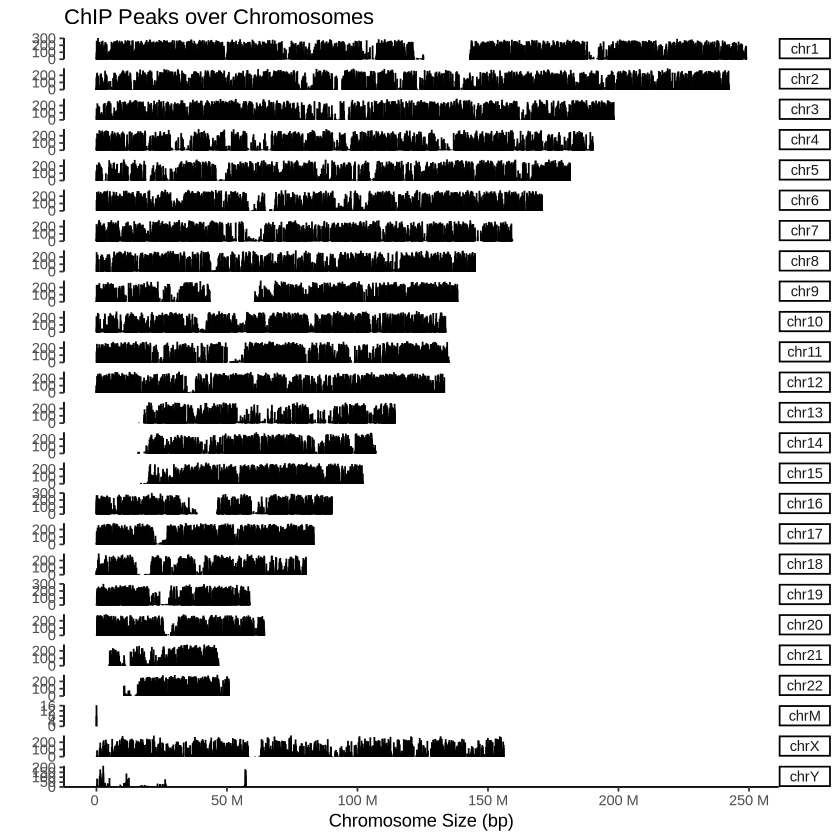

In [10]:
covplot(rep2,weightCol=5)

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


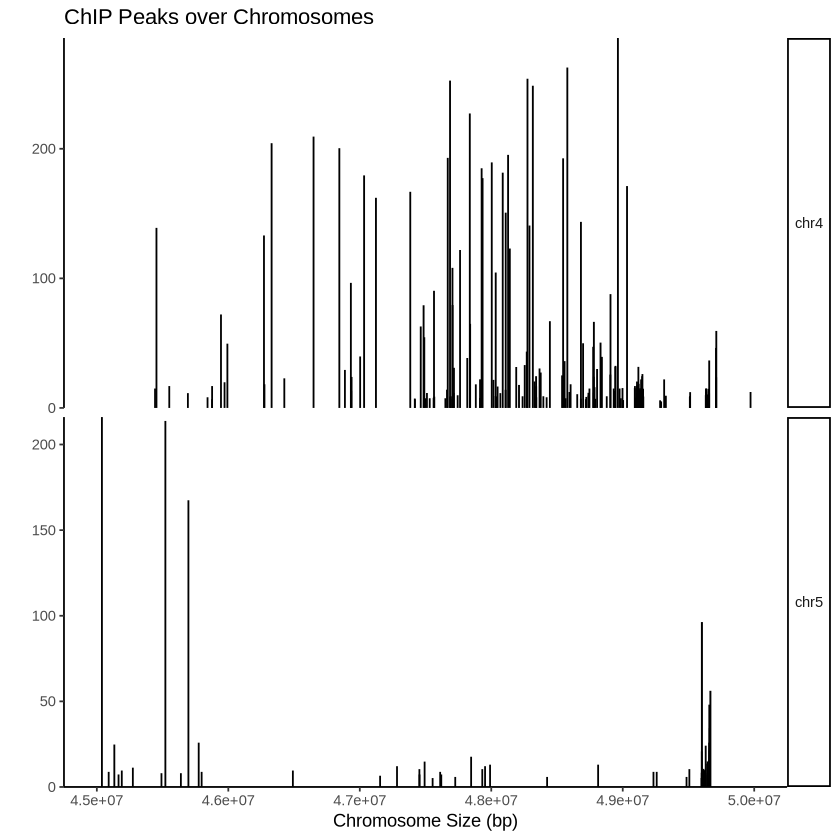

In [11]:
covplot(rep2, weightCol=5, chrs=c("chr4", "chr5"), xlim=c(4.5e7, 5e7))

In [12]:
promoter <- getPromoters(TxDb=txdb, upstream=3000, downstream=3000)

In [13]:
rep2

GRanges object with 142758 ranges and 7 metadata columns:
           seqnames            ranges strand |   rep2_peak_3822      X272
              <Rle>         <IRanges>  <Rle> |      <character> <integer>
       [1]     chr1       11153-11520      * |   rep2_peak_3823       964
       [2]     chr1       16194-16363      * |   rep2_peak_3824        79
       [3]     chr1       25999-26158      * |   rep2_peak_3825        83
       [4]     chr1       29236-29457      * |   rep2_peak_3826       101
       [5]     chr1       91174-91697      * |   rep2_peak_3827      2586
       ...      ...               ...    ... .              ...       ...
  [142754]     chrY 57153447-57153700      * | rep2_peak_146576       168
  [142755]     chrY 57158270-57158470      * | rep2_peak_146577       120
  [142756]     chrY 57203180-57203553      * | rep2_peak_146578      1069
  [142757]     chrY 57215079-57215432      * | rep2_peak_146579       438
  [142758]     chrY 57216780-57217328      * | rep2_pe

In [14]:
tagMatrix <- getTagMatrix(rep2, windows=promoter)

>> preparing start_site regions by gene... 2025-01-23 05:42:33 AM
>> preparing tag matrix...  2025-01-23 05:42:33 AM 


In [15]:
?tagHeatmap

tagHeatmap {ChIPseeker},R Documentation
tagMatrix,tagMatrix or a list of tagMatrix
xlab,xlab
ylab,ylab
title,title
palette,"palette to be filled in,details see scale_colour_brewer"
nrow,the nrow of plotting a list of peak
ncol,the ncol of plotting a list of peak


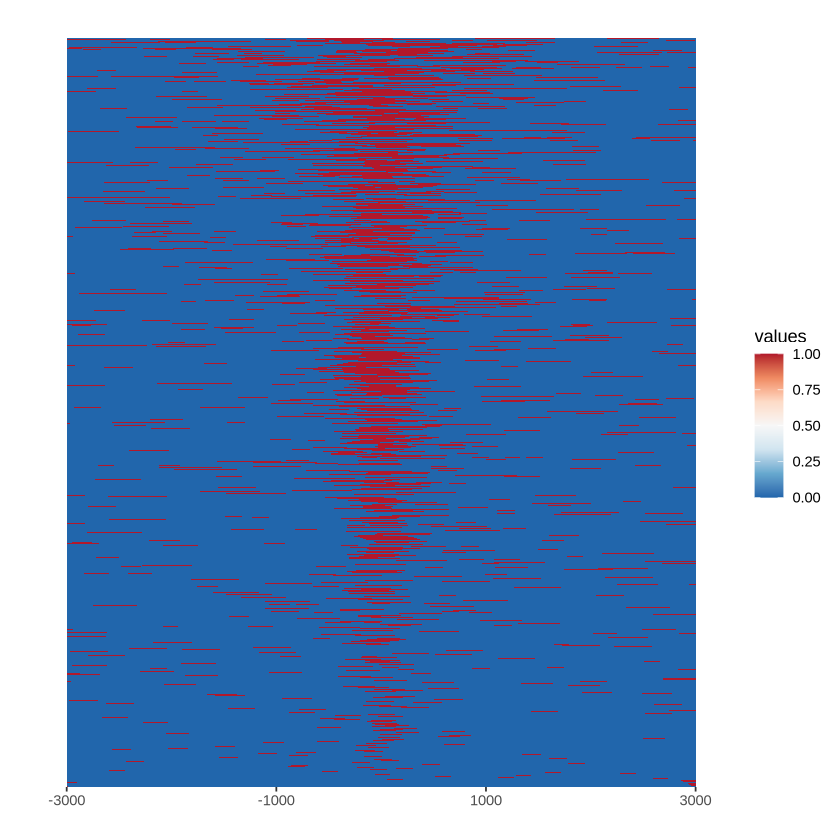

In [16]:
tagHeatmap(tagMatrix)

>> preparing promoter regions...	 2025-01-23 05:55:04 AM 
>> preparing tag matrix...		 2025-01-23 05:55:04 AM 
>> preparing start_site regions by gene... 2025-01-23 05:55:04 AM
>> preparing tag matrix...  2025-01-23 05:55:04 AM 
>> generating figure...		 2025-01-23 05:55:10 AM 
>> done...			 2025-01-23 05:55:17 AM 


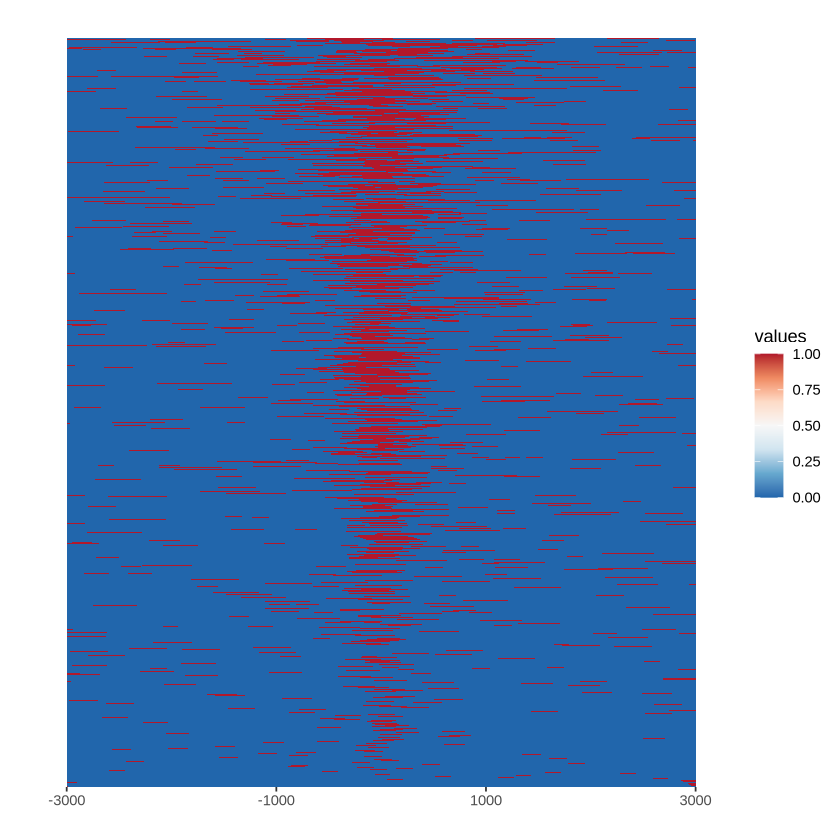

In [17]:
peakHeatmap(rep2, TxDb=txdb, upstream=3000, downstream=3000)

>> plotting figure...			 2025-01-23 06:01:50 AM 
>> Running bootstrapping for tag matrix...		 2025-01-23 06:02:30 AM 


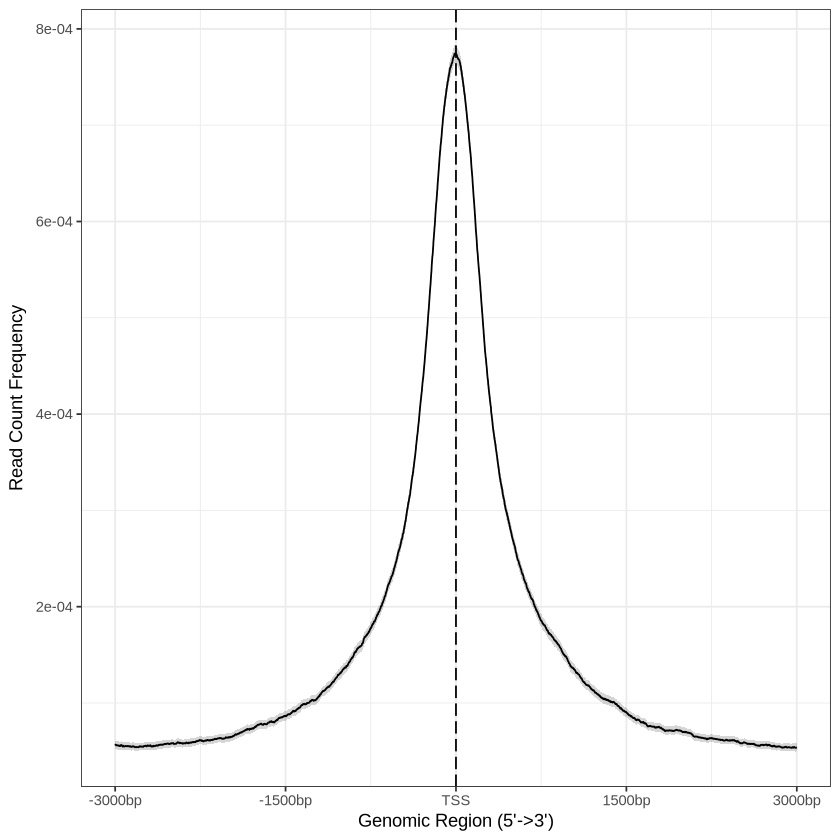

In [18]:
plotAvgProf(tagMatrix, xlim=c(-3000, 3000),
            conf=0.95,resample = 1000,
            xlab="Genomic Region (5'->3')", ylab = "Read Count Frequency")

In [19]:
peakAnno <- annotatePeak(rep2, tssRegion=c(-3000, 3000),
                         TxDb=txdb, annoDb="org.Hs.eg.db")

>> preparing features information...		 2025-01-23 06:02:32 AM 
>> identifying nearest features...		 2025-01-23 06:02:33 AM 
>> calculating distance from peak to TSS...	 2025-01-23 06:02:35 AM 
>> assigning genomic annotation...		 2025-01-23 06:02:35 AM 
>> adding gene annotation...			 2025-01-23 06:03:03 AM 


'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2025-01-23 06:03:04 AM 
>> done...					 2025-01-23 06:03:04 AM 


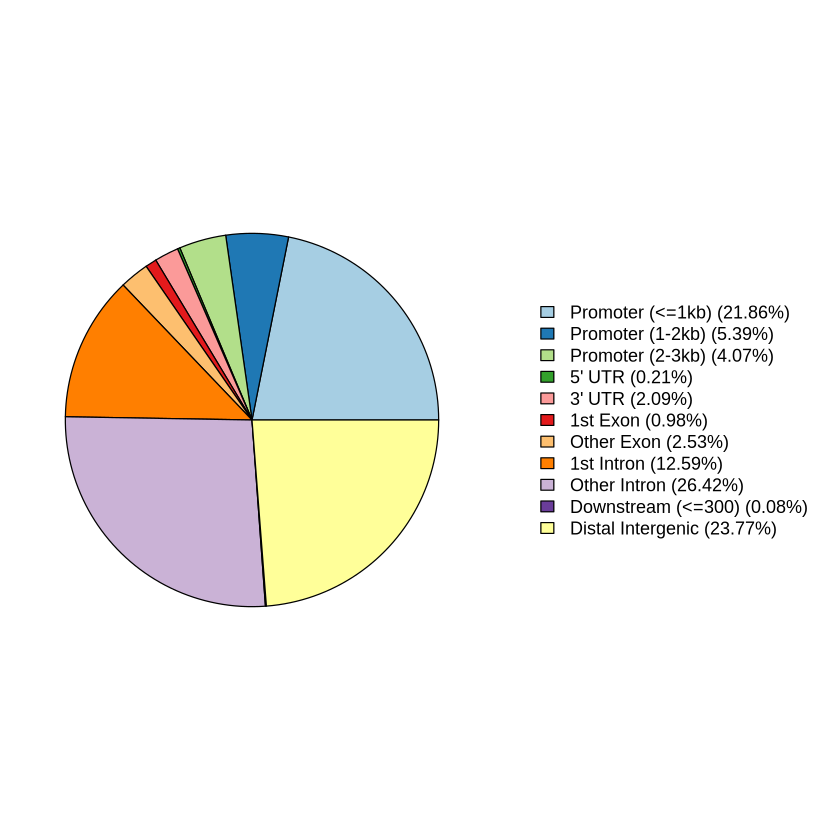

In [20]:
plotAnnoPie(peakAnno)


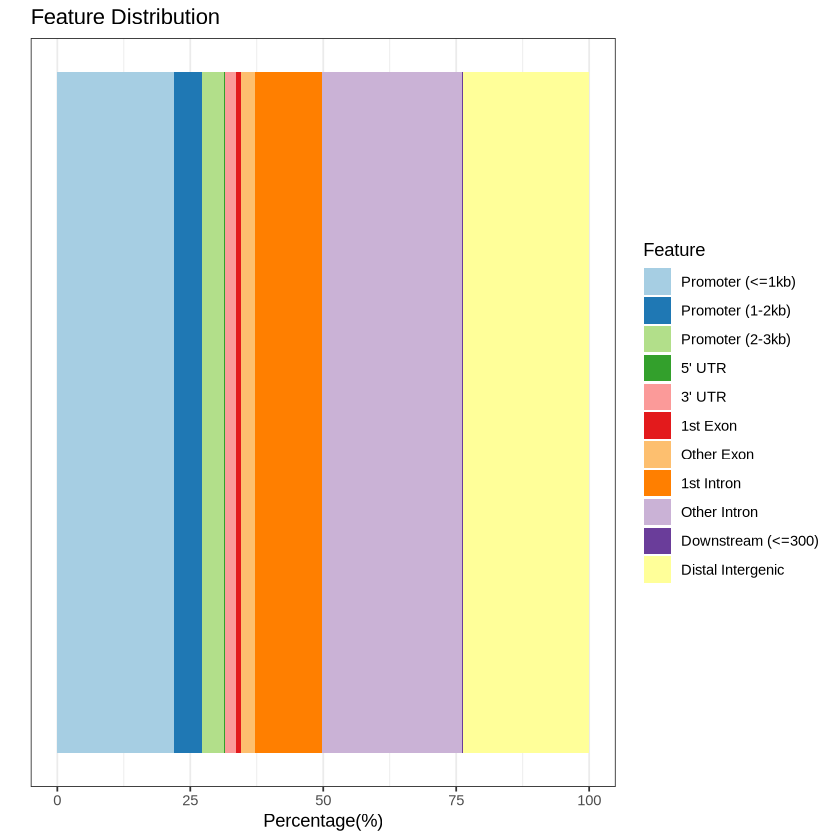

In [21]:
plotAnnoBar(peakAnno)


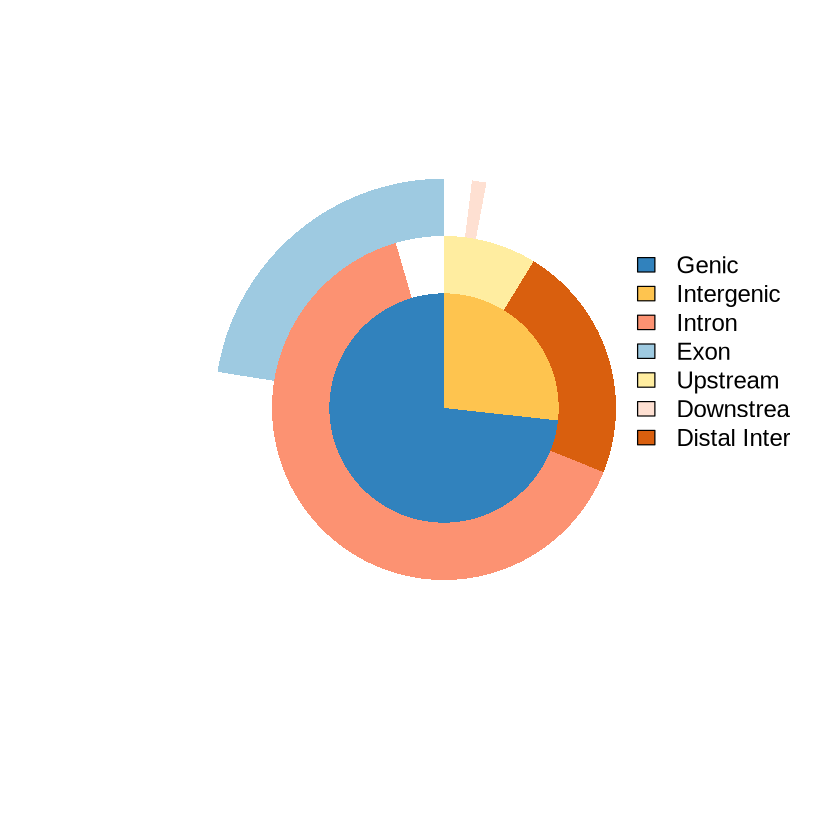

In [22]:
vennpie(peakAnno)


Warning message:
“Removed 810 rows containing non-finite outside the scale range (`stat_count()`).”


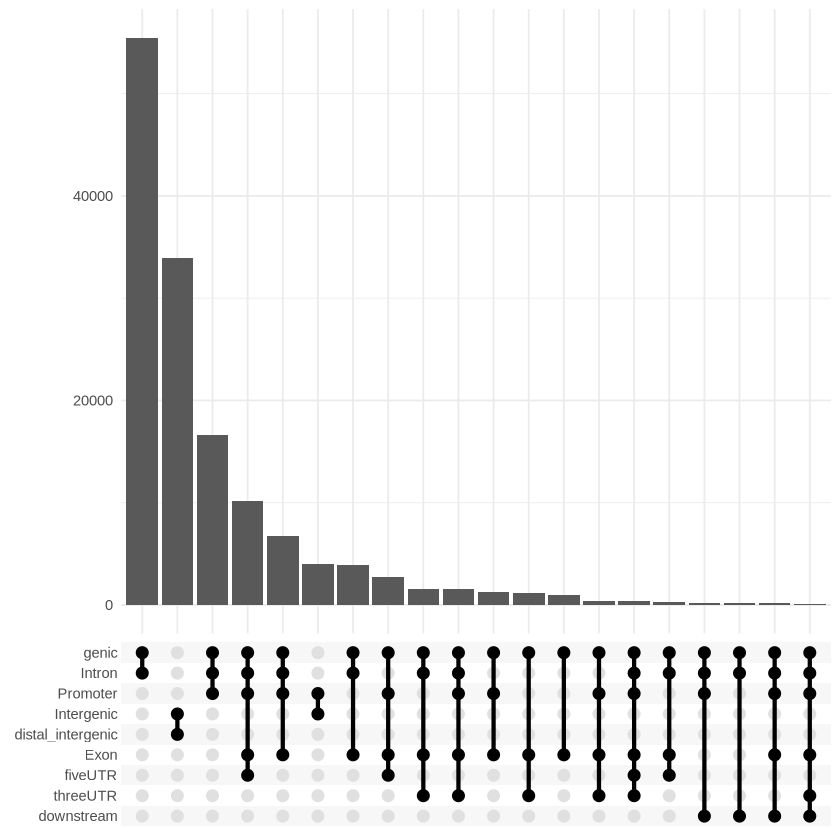

In [23]:
upsetplot(peakAnno)


Warning message:
“Removed 810 rows containing non-finite outside the scale range (`stat_count()`).”


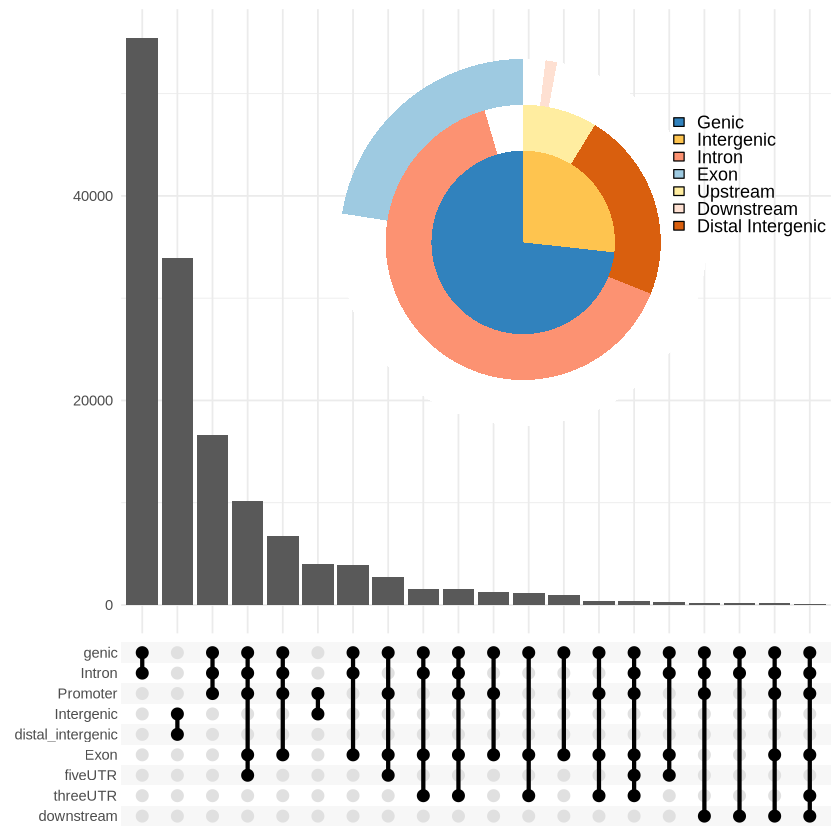

In [24]:
upsetplot(peakAnno, vennpie=TRUE)


In [25]:
peakAnnoList <- as.data.frame(peakAnno)

In [26]:
dim(peakAnnoList)
head(peakAnnoList)

[1] 142756     24

,seqnames,start,end,width,strand,rep2_peak_3822,X272,.,X8.01657,X29.71469,⋯,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME
,<fct>,<int>,<int>,<int>,<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,11153,11520,368,*,rep2_peak_3823,964,.,16.50262,99.39271,⋯,11869,14409,2541,1,100287102,ENST00000456328.2,-349,ENSG00000290825,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene)
2,chr1,16194,16363,170,*,rep2_peak_3824,79,.,4.27029,10.05656,⋯,17369,17436,68,2,102466751,ENST00000619216.1,1073,ENSG00000278267,MIR6859-1,microRNA 6859-1
3,chr1,25999,26158,160,*,rep2_peak_3825,83,.,4.45030,10.50144,⋯,14696,24886,10191,2,653635,ENST00000488147.2,-1113,NA,WASH7P,"WASP family homolog 7, pseudogene"
4,chr1,29236,29457,222,*,rep2_peak_3826,101,.,5.05443,12.28055,⋯,29554,31097,1544,1,107985730,ENST00000473358.1,-97,NA,MIR1302-2HG,MIR1302-2 host gene
5,chr1,91174,91697,524,*,rep2_peak_3827,2586,.,23.42253,263.63528,⋯,65419,71585,6167,1,79501,ENST00000641515.2,25755,ENSG00000186092,OR4F5,olfactory receptor family 4 subfamily F member 5
6,chr1,102681,103075,395,*,rep2_peak_3828,168,.,5.65931,19.15587,⋯,92230,129217,36988,2,124900384,ENST00000477740.5,26142,NA,LOC124900384,uncharacterized LOC124900384


In [27]:
genes<-peakAnnoList$geneId
head(genes)

[1] "100287102" "102466751" "653635"    "107985730" "79501"     "124900384"

In [28]:
geneSym<-peakAnnoList$SYMBOL
head(geneSym)
length(geneSym)
length(unique(geneSym))

[1] "DDX11L1"      "MIR6859-1"    "WASH7P"       "MIR1302-2HG"  "OR4F5"       
[6] "LOC124900384"

[1] 142756

[1] 26482

In [29]:
write.csv(peakAnnoList, "Rep2_peak_anno.csv", quote = F)